<a href="https://colab.research.google.com/github/fatenmegahed/npro/blob/main/Weather-Based%20Renewable%20Energy%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score ,r2_score,mean_squared_error

In [3]:
df = pd.read_csv(r"/content/sample_data/weather.csv")
df

,Pressure,global_radiation,temp_mean(c),temp_min(c),temp_max(c),Wind_Speed,Wind_Bearing,normalized_label
0,971.5,0.25,9.0,7.0,10.7,0.00,0.0,0.0
1,972.3,0.97,10.5,6.7,13.5,0.00,0.0,0.0
2,972.4,0.74,6.5,3.9,9.1,0.00,0.0,0.0
3,973.2,0.15,5.1,3.7,7.7,0.00,0.0,0.0
4,975.7,0.12,5.2,2.6,8.3,0.00,0.0,0.0
...,...,...,...,...,...,...,...,...
56664,1007.3,1.18,7.6,5.2,9.6,38.04,312.0,2.0
56665,1007.3,1.18,7.6,5.2,9.6,16.82,159.0,2.0
56666,1007.3,1.18,7.6,5.2,9.6,14.04,140.0,0.0
56667,1007.3,1.18,7.6,5.2,9.6,5.67,37.0,0.0


In [4]:
df.head()

,Pressure,global_radiation,temp_mean(c),temp_min(c),temp_max(c),Wind_Speed,Wind_Bearing,normalized_label
0,971.5,0.25,9.0,7.0,10.7,0.0,0.0,0.0
1,972.3,0.97,10.5,6.7,13.5,0.0,0.0,0.0
2,972.4,0.74,6.5,3.9,9.1,0.0,0.0,0.0
3,973.2,0.15,5.1,3.7,7.7,0.0,0.0,0.0
4,975.7,0.12,5.2,2.6,8.3,0.0,0.0,0.0


In [5]:
df.sample(5)

,Pressure,global_radiation,temp_mean(c),temp_min(c),temp_max(c),Wind_Speed,Wind_Bearing,normalized_label
48323,1007.0,0.90,7.8,1.8,13.1,19.72,349.0,3.0
23833,1005.0,0.38,4.6,1.3,8.5,18.87,151.0,2.0
52406,1007.1,0.34,1.1,-1.2,4.0,12.59,38.0,0.0
31357,1005.8,1.91,19.4,16.6,23.9,9.66,190.0,0.0
39787,1006.5,1.25,14.2,11.8,16.8,14.49,270.0,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56669 entries, 0 to 56668
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Pressure          56669 non-null  float64
 1   global_radiation  56669 non-null  float64
 2   temp_mean(c)      56668 non-null  float64
 3   temp_min(c)       56668 non-null  float64
 4   temp_max(c)       56668 non-null  float64
 5   Wind_Speed        56668 non-null  float64
 6   Wind_Bearing      56668 non-null  float64
 7   normalized_label  56668 non-null  float64
dtypes: float64(8)
memory usage: 3.5 MB


In [ ]:
df['temp_max(c)'].min()

-6.6

In [ ]:
df['Wind_Speed'].mean()

np.float64(14.054926885832138)

In [7]:
df.duplicated().sum()

np.int64(735)

In [11]:
df.isnull().sum()

,0
Pressure,0
global_radiation,0
temp_mean(c),0
temp_min(c),0
temp_max(c),0
Wind_Speed,0
Wind_Bearing,0
normalized_label,0


In [10]:
df.fillna(df.mean(),inplace=True)

In [9]:
df.describe()

,Pressure,global_radiation,temp_mean(c),temp_min(c),temp_max(c),Wind_Speed,Wind_Bearing,normalized_label
count,56669.000000,56669.000000,56668.000000,56668.000000,56668.000000,56668.000000,56668.000000,56668.000000
mean,1004.525998,0.889209,9.947625,6.700524,13.428321,15.177430,196.640538,1.068398
std,3.030781,0.700287,5.689553,5.451156,6.456869,8.761529,97.587694,1.070848
min,971.500000,0.030000,-10.500000,-15.300000,-6.600000,0.000000,0.000000,0.000000
25%,1003.400000,0.320000,5.900000,2.600000,8.900000,9.450000,140.000000,0.000000
50%,1005.500000,0.690000,9.700000,6.800000,12.900000,13.850000,190.000000,1.000000
75%,1006.700000,1.330000,14.300000,11.100000,17.900000,20.930000,280.000000,2.000000
max,1007.300000,3.380000,27.100000,21.400000,36.200000,45.080000,359.000000,3.000000


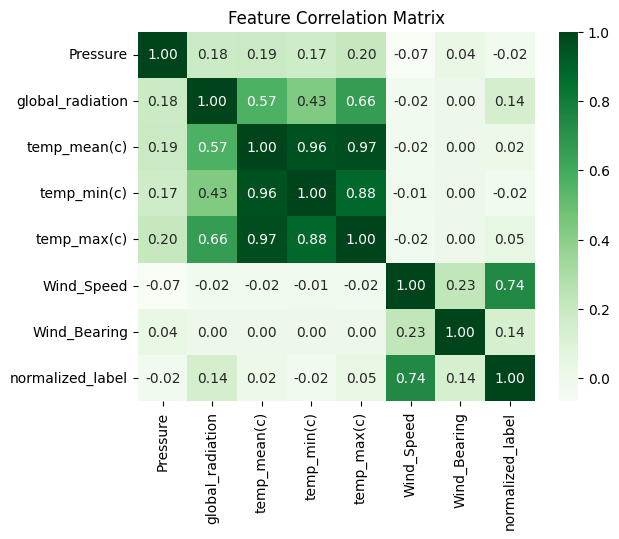

In [12]:
sns.heatmap(df.corr(),annot=True,cmap='Greens',fmt='.2f')
plt.title("Feature Correlation Matrix")
plt.show()

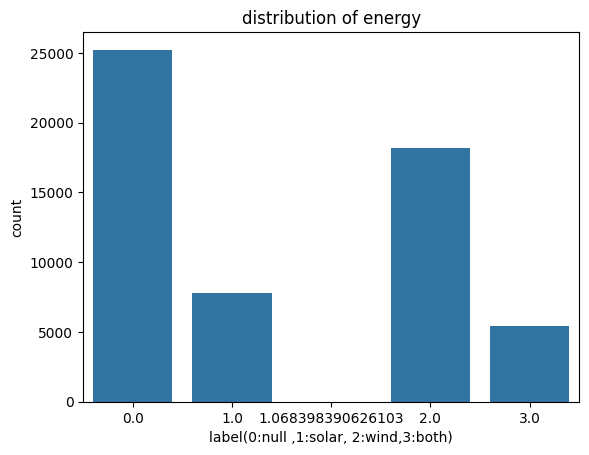

In [14]:
sns.countplot(data=df,x='normalized_label')
plt.title('distribution of energy')
plt.xlabel('label(0:null ,1:solar, 2:wind,3:both)')
plt.ylabel('count')
plt.show()

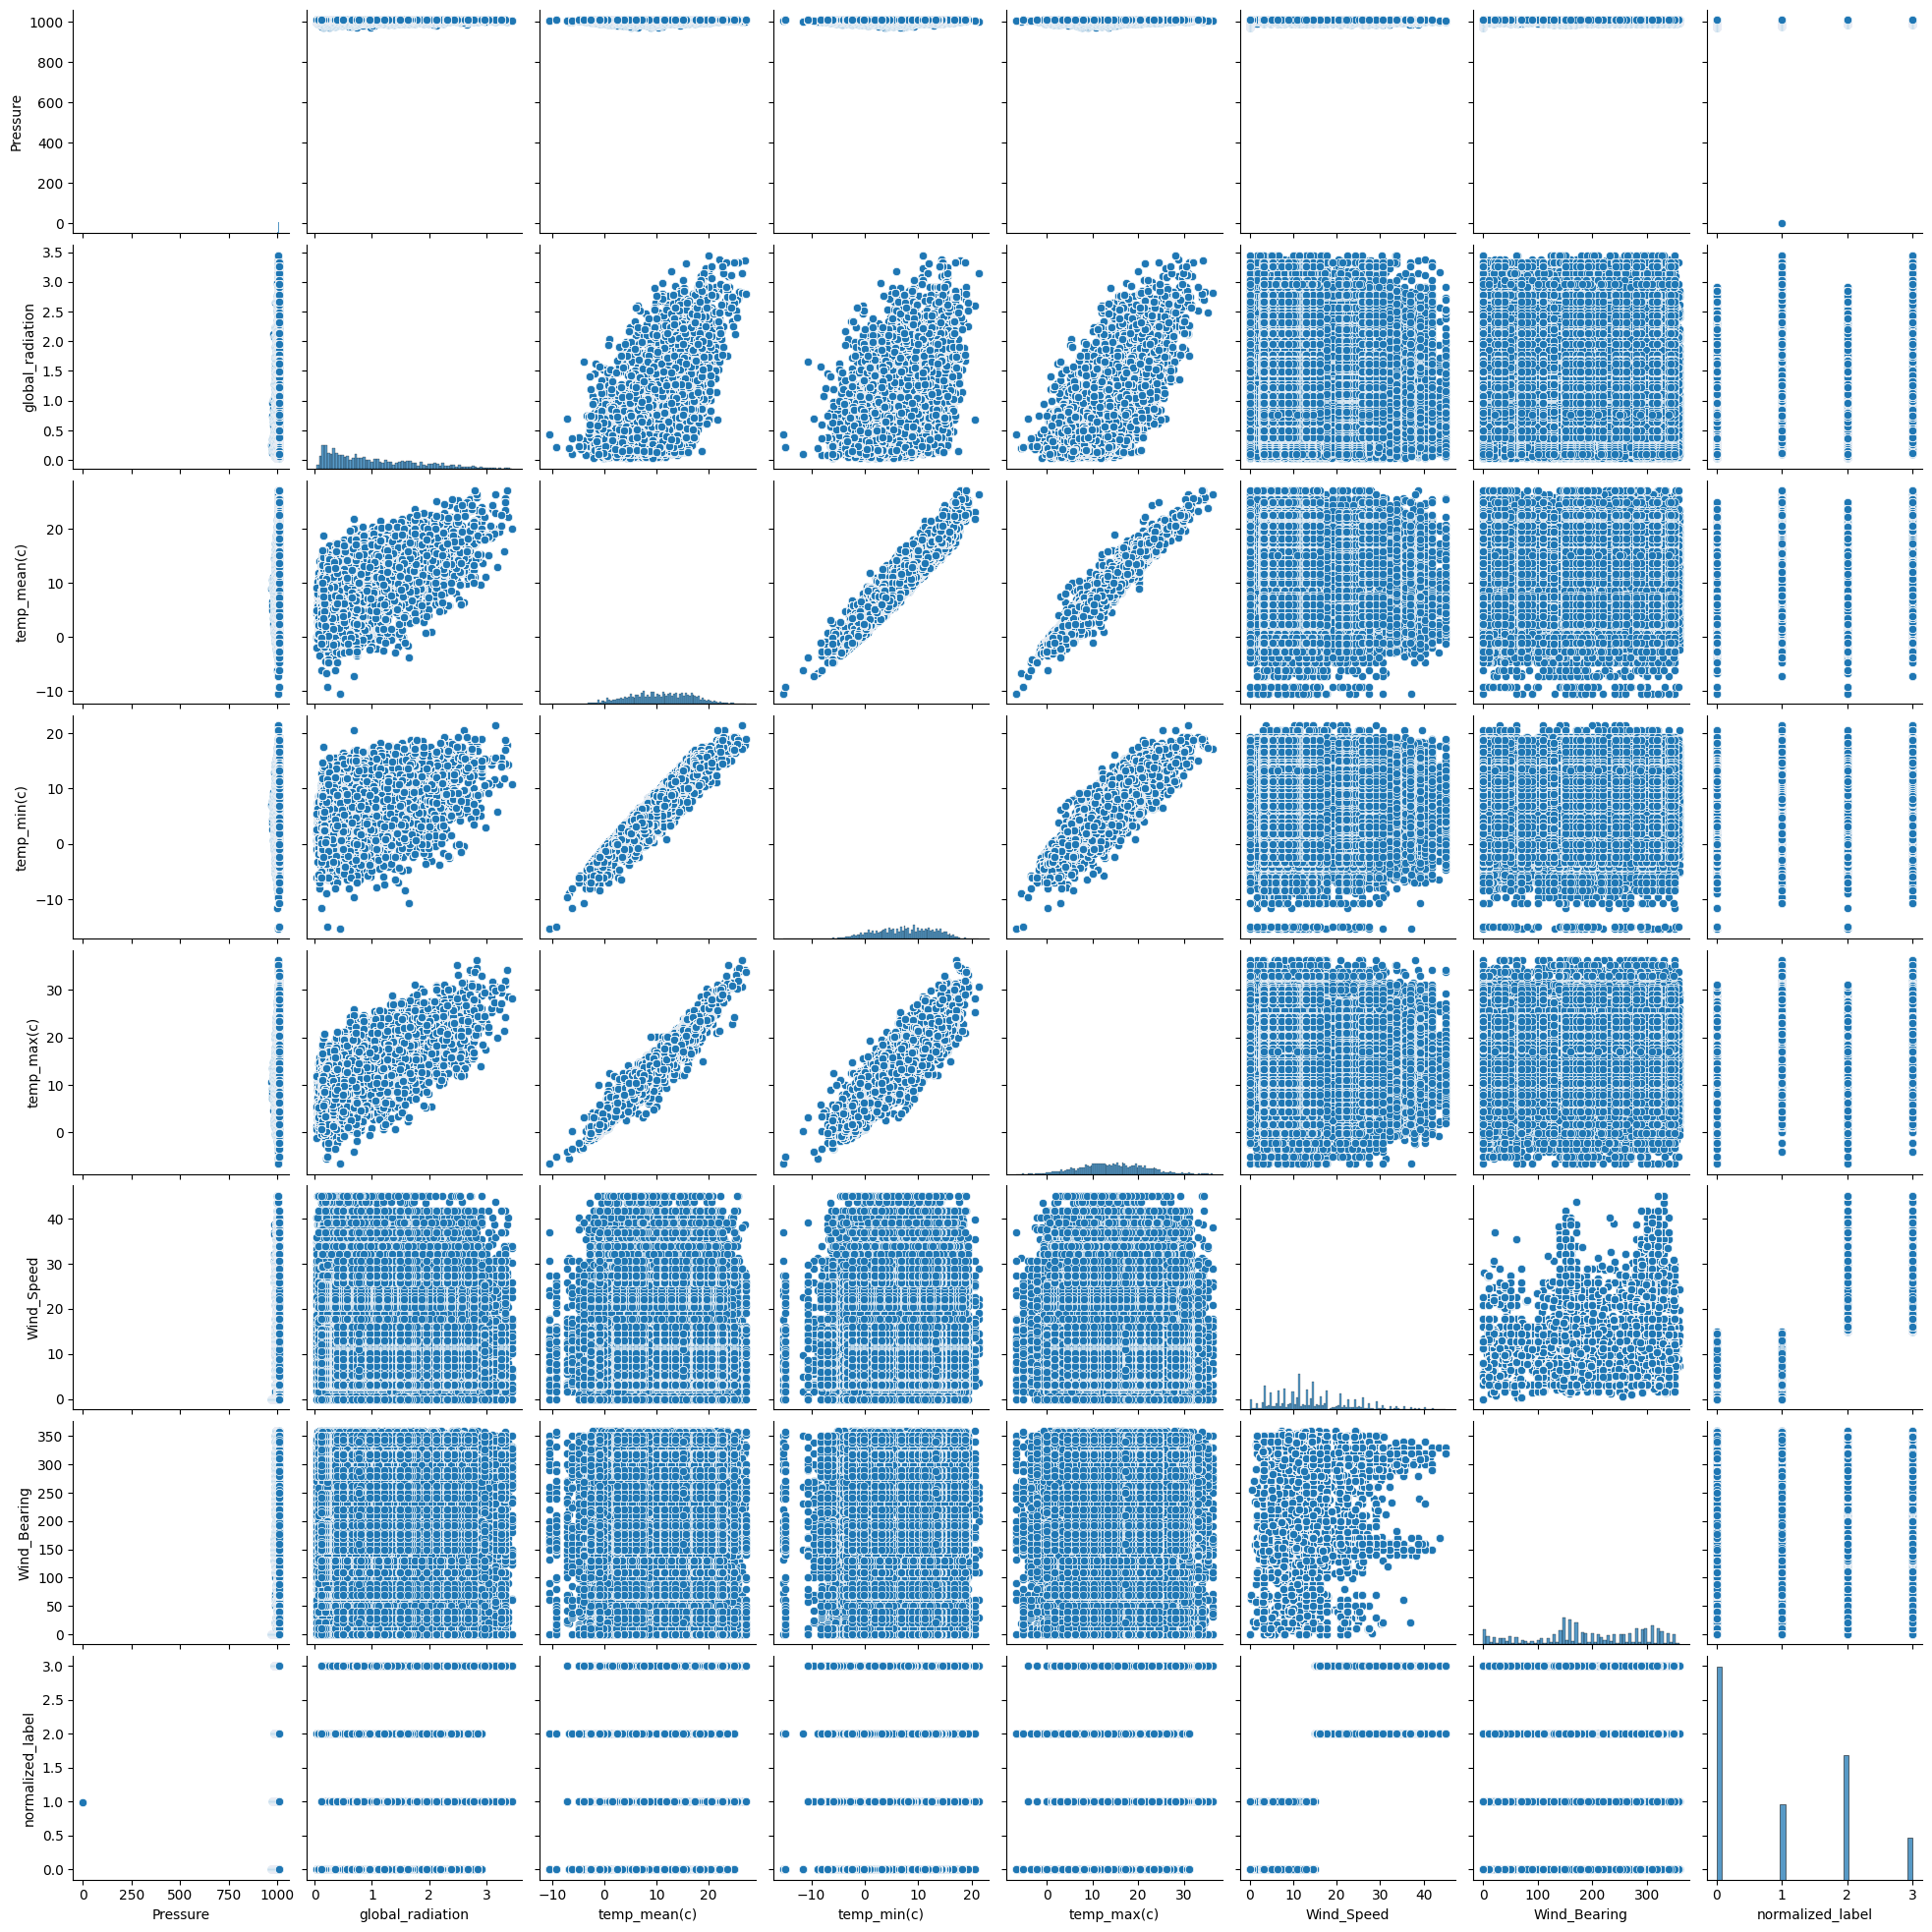

In [ ]:
sns.pairplot(df)

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [16]:
x=df.drop('normalized_label',axis=1)
y=df['normalized_label']

In [ ]:
df['normalized_label'].fillna(df['normalized_label'].mean(),inplace=True)

In [17]:
from sklearn.preprocessing import StandardScaler



In [18]:
scal=StandardScaler()
df['normalized_label']=scal.fit_transform(df[['normalized_label']])


In [41]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.15,random_state=42)
x_train_scaled = scal.fit_transform(x_train)
x_test_scaled = scal.transform(x_test)

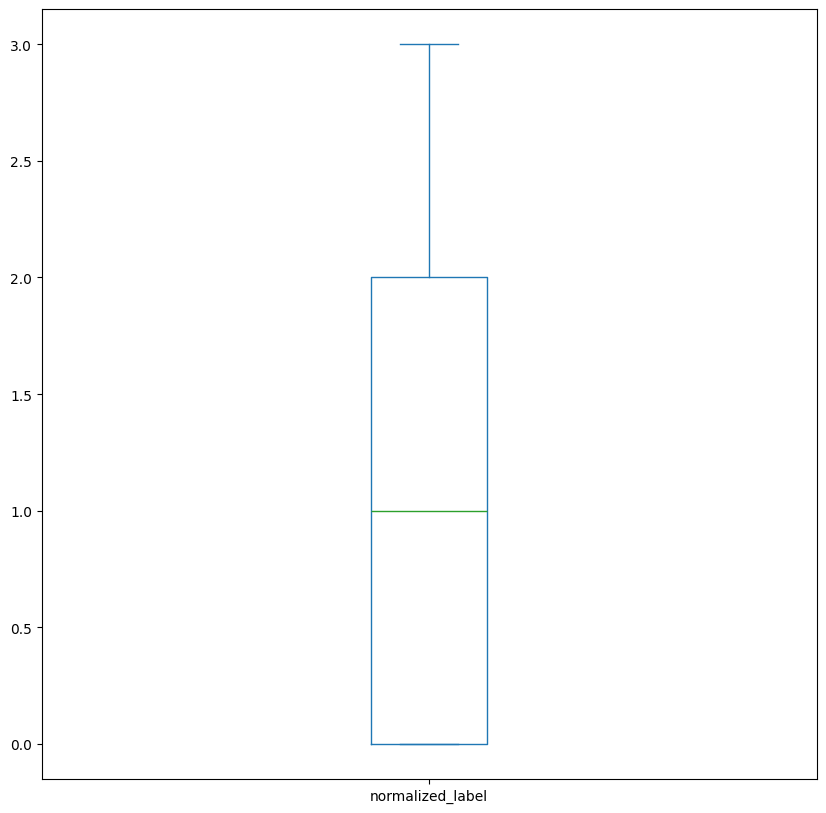

In [ ]:
plt.figure(figsize=(10,10))
df['normalized_label'].plot(kind='box',subplots=True,layout=(2,3),sharex=False,sharey=False)
plt.show()

In [21]:
from sklearn.ensemble import RandomForestClassifier

In [22]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [42]:
rf=RandomForestClassifier()

rf.fit(X_train_scaled,y_train.astype(int))

y_pred=rf.predict(x_test_scaled)
print('acc=',accuracy_score(y_test.astype(int),y_pred))
print('clac=',classification_report(y_test.astype(int),y_pred))

acc= 0.9897659098929538
clac=               precision    recall  f1-score   support

           0       0.99      1.00      0.99      3664
           1       0.99      0.96      0.98      1217
           2       0.99      1.00      0.99      2763
           3       1.00      0.96      0.98       857

    accuracy                           0.99      8501
   macro avg       0.99      0.98      0.99      8501
weighted avg       0.99      0.99      0.99      8501



In [25]:
con=confusion_matrix(y_test,y_pred)
print(con)

[[3659    5    0    0]
 [  41 1176    0    0]
 [   0    0 2762    1]
 [   0    0   23  834]]


<function matplotlib.pyplot.show(close=None, block=None)>

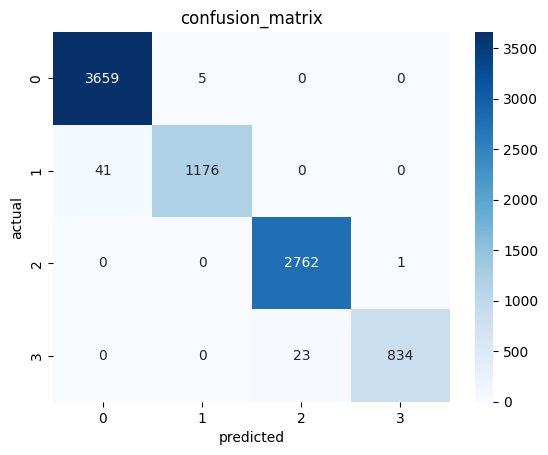

In [28]:
sns.heatmap(con,annot=True,cmap='Blues',fmt='d',xticklabels=[0,1,2,3],yticklabels=[0,1,2,3])
plt.title('confusion_matrix')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.show